In [1]:
import jijmodeling as jm

problem = jm.Problem("Graph Partitioning")


@problem.update
def _(problem: jm.DecoratedProblem):
    V = problem.Dim()
    E = problem.Natural(ndim=2)  # edge list: [[u1,v1], [u2,v2], ...]
    x = problem.BinaryVar(shape=(V,))

    # Objective: minimize edges cut between partitions
    problem += (
        E.rows().map(lambda e: x[e[0]] * (1 - x[e[1]]) + x[e[1]] * (1 - x[e[0]])).sum()
    )

    # Constraint: equal partition sizes
    problem += problem.Constraint("Equal Partition", x.sum() == V / 2)


problem

Problem(name="Graph Partitioning", sense=MINIMIZE, objective=sum(E.rows().map(lambda (e: Array[:; natural]): x[e[0]] * (1 - x[e[1]]) + x[e[1]] * (1 - x[e[0]]))), constraints={Equal Partition: [Constraint(name="Equal Partition", sense=EQUAL, left=sum(x), right=V / 2, shape=Scalar(Float)),],})

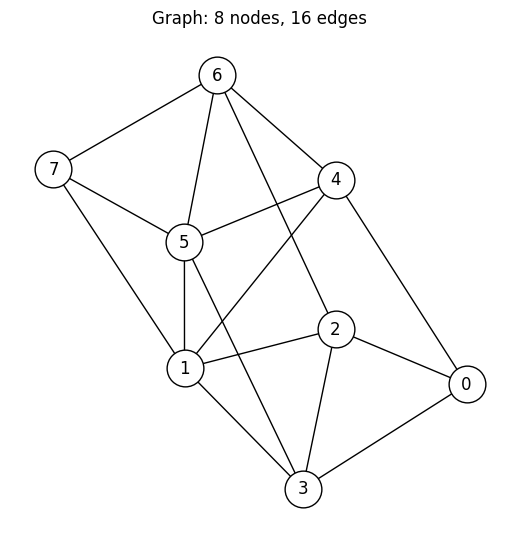

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

num_nodes = 8
edge_list = [
    [0, 2],
    [0, 3],
    [0, 4],
    [1, 2],
    [1, 3],
    [1, 4],
    [1, 5],
    [1, 7],
    [2, 3],
    [2, 6],
    [3, 5],
    [4, 5],
    [4, 6],
    [5, 6],
    [5, 7],
    [6, 7],
]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_list)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

In [3]:
instance_data = {"V": num_nodes, "E": edge_list}
instance = problem.eval(instance_data)

In [ ]:
from qamomile.optimization.gas import GASConverter
from qamomile.qiskit import QiskitTranspiler

converter = GASConverter(instance)
transpiler = QiskitTranspiler()

exec = converter.transpile(transpiler, output_bits=6, y=0, num_iterations=1)

SampleSet(raw=<builtins.SampleSet object at 0x77cb87178920>, annotations={})

In [29]:
from qiskit_aer import AerSimulator

executor = transpiler.executor(backend=AerSimulator(seed_simulator=901))

def run_grover_algorithm(
    n: int,
    m: int,
    y: int,
    offset: int,
    linear: dict[int, float],
    quad: dict[tuple[int, int], float],
    number_iters: int,
    shots: int = 256,
    seed: int = 900,
):
    """Run the Grover circuit for a fixed number of iterations and return the best sampled candidate."""
    def _extract_x(c):
        # candidate format: (((q_output_bits), (q_input_bits)), count)
        return list(c[0][1])

    job = exec.sample(executor, shots=512)
    result = job.result()
    decoded = converter.decode(result)

    best = decoded.best_feasible
    x_vals = best.extract_decision_variables("x")   # {(0,): 1.0, (1,): 0.0, ...}
    best_x = "".join(str(int(round(x_vals[(i,)]))) for i in range(num_nodes))
    best_value = best.objective

    return best_x, best_value

In [53]:
x,y = run_grover_algorithm(
    n=converter.spin_model.num_bits,
    m=6,
    y=7,
    offset=0,
    linear=converter.spin_model.linear,
    quad=converter.spin_model.quad,
    number_iters=1,
)

In [61]:
from typing import Any
import numpy as np

import random
import ommx

def grover_adaptive_search(
    m: int,
    converter: Any,
    lamb: float,
    verbose: bool = False,
    max_iter : int = np.inf,
    max_no_improvement : int = 5,
):
    """Grover Adaptive Search algorithm for optimization problems.

    Parameters
    ----------
    m : int
        The size of the function image domain.
    offset : int
        The constant term in the objective function.
    linear : dict[int, float]
        The linear coefficients of the objective function, where the key is the bit index and the value is the coefficient.
    quad : dict[tuple[int, int], float]
        The quadratic coefficients of the objective function, where the key is a tuple of bit indices and the value is the coefficient.
    lamb : float
        The parameter controlling the search.
    verbose : bool, default=False
        If True, prints a detailed trace of each adaptive-search iteration.
    max_iter : int, default=np.inf
        Maximum number of iterations before stopping the algorithm.
    max_no_improvement : int, default=5
        Maximum number of consecutive iterations without improvement before stopping the algorithm.

    Returns
    -------
    solution : tuple[list[int], float]
        The solution (x, y) found by the algorithm.
    """

    n = converter.spin_model.num_bits

    k = 1
    x_int = random.randint(0, 2**n - 1)
    x = [int(b) for b in format(x_int, f"0{n}b")]
    y = converter.instance.evaluate({i : x_i for i, x_i in enumerate(x)}).objective

    oracle_calls = 0
    current_iter = 0
    no_improvement_count = 0

    if verbose:
        print("[GAS] Initialization")
        print(f"[GAS] n={n}, m={m}, lambda={lamb}")
        print(f"[GAS] Start state: x={x}, y={y}, k={k}")

    stop = False
    while not stop:
        # Sample t uniformly in {0, ..., ceil(k)-1}; avoid empty range when k == 1
        num_iterations = random.randrange(max(1, int(np.ceil(k))))

        if verbose:
            print("\n" + "-" * 72)
            print(
                f"[GAS] Iteration {current_iter + 1} | current y={y}, k={k:.6f}, "
                f"Grover iters={num_iterations}"
            )

        candidate_x, candidate_y = run_grover_algorithm(
            n=converter.spin_model.num_bits,
            m=m,
            y=y,
            offset=0,
            linear=converter.spin_model.linear,
            quad=converter.spin_model.quad,
            number_iters=num_iterations,
        )

        if verbose:
            print(f"[GAS] Candidate: x={candidate_x}, y={candidate_y}")

        if candidate_y < y:
            if verbose:
                print("[GAS] Improvement found -> accepting candidate and resetting k to 1")
            x = candidate_x
            y = candidate_y
            k = 1
            no_improvement_count = 0
        else:
            old_k = k
            k = lamb * k
            no_improvement_count += 1
            if verbose:
                print(
                    f"[GAS] No improvement -> keeping current solution and scaling "
                    f"k: {old_k:.6f} -> {k:.6f}"
                )

        current_iter += 1
        oracle_calls += num_iterations
        stop = (current_iter >= max_iter) or (oracle_calls >= 10 * n) or (no_improvement_count >= max_no_improvement)

    stop_reasons = []
    if current_iter >= max_iter:
        stop_reasons.append(f"reached max_iter ({current_iter}/{max_iter})")
    if oracle_calls >= 10 * n:
        stop_reasons.append(f"oracle call budget reached ({oracle_calls}/{10 * n})")
    if no_improvement_count >= max_no_improvement:
        stop_reasons.append(
            f"no improvement for {max_no_improvement} consecutive iterations"
        )
    if not stop_reasons:
        stop_reasons.append("stop condition triggered")

    if verbose:
        print("\n" + "=" * 72)
        print(f"[GAS] Finished after {current_iter} iterations. Best found: x={x}, y={y}")
        print(f"[GAS] Stop reason(s): {'; '.join(stop_reasons)}")

    return x, y

In [62]:
grover_adaptive_search(
    m=6,
    converter=converter,
    lamb=1.5,
    verbose=True,
    max_iter=20,
    max_no_improvement=5,
)

[GAS] Initialization
[GAS] n=8, m=6, lambda=1.5
[GAS] Start state: x=[0, 1, 0, 0, 1, 1, 0, 0], y=9.0, k=1

------------------------------------------------------------------------
[GAS] Iteration 1 | current y=9.0, k=1.000000, Grover iters=0
[GAS] Candidate: x=00001111, y=6.0
[GAS] Improvement found -> accepting candidate and resetting k to 1

------------------------------------------------------------------------
[GAS] Iteration 2 | current y=6.0, k=1.000000, Grover iters=0
[GAS] Candidate: x=00001111, y=6.0
[GAS] No improvement -> keeping current solution and scaling k: 1.000000 -> 1.500000

------------------------------------------------------------------------
[GAS] Iteration 3 | current y=6.0, k=1.500000, Grover iters=0
[GAS] Candidate: x=00001111, y=6.0
[GAS] No improvement -> keeping current solution and scaling k: 1.500000 -> 2.250000

------------------------------------------------------------------------
[GAS] Iteration 4 | current y=6.0, k=2.250000, Grover iters=2
[GAS] C

('00001111', 6.0)